**A botanist wants to classify different iris species based on their flower characteristics like sepal length, sepal width, petal length, and petal width.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

In [ ]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [ ]:
print("\nDuplicate Rows:", df.duplicated().sum())
df= df.drop_duplicates()


Duplicate Rows: 1


In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

K-Means divides data into k groups (clusters) such that:

Each data point belongs to the nearest cluster center (centroid).

The centroids are updated repeatedly to minimize the total distance between data points and their assigned centroid.

In [ ]:
scores = []
range_of_clusters = range(1, 11)

for k in range_of_clusters:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(scaled_data)
    scores.append(kmeans.inertia_)

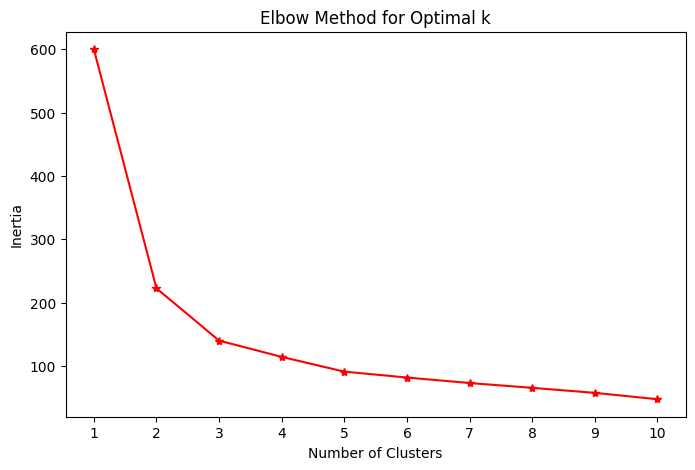

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range_of_clusters, scores, 'r*-')
plt.xticks(range_of_clusters)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


Inertia decreases sharply up to k = 3, then flattens, forming an “elbow.” Beyond k = 3, adding more clusters gives little improvement. Optimal number of clusters for the Iris dataset is 3.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(scaled_data)


KMeans(n_clusters=3, random_state=0)

In [ ]:
cluster_centers = pd.DataFrame(data=kmeans.cluster_centers_, columns=iris.feature_names)
print("Cluster Centers (Standardized Values):")
print(cluster_centers)


Cluster Centers (Standardized Values):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.050220         -0.883376           0.347738          0.281527
1          -1.014579          0.853263          -1.304987         -1.254893
2           1.135970          0.088422           0.996155          1.017526


**Cluster 1:** All features below average → likely Iris Setosa (small petals).<br>
**Cluster 0:** Sepal average, petal slightly above average → likely Iris Versicolor (medium petals).<br>
**Cluster 2:** Features above average → likely Iris Virginica (large petals).

In [ ]:
X_df = pd.DataFrame(X, columns=iris.feature_names)
cluster_labels = pd.DataFrame(kmeans.labels_, columns=['CLUSTER'])
X_with_clusters = pd.concat([X_df, cluster_labels], axis=1)

In [ ]:
# Show first 5 rows of each cluster
for cluster in sorted(X_with_clusters['CLUSTER'].unique()):
    print(f"\nCluster {cluster} samples:")
    print(X_with_clusters[X_with_clusters['CLUSTER'] == cluster].head())



Cluster 0 samples:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
53                5.5               2.3                4.0               1.3   
54                6.5               2.8                4.6               1.5   
55                5.7               2.8                4.5               1.3   
57                4.9               2.4                3.3               1.0   
58                6.6               2.9                4.6               1.3   

    CLUSTER  
53        0  
54        0  
55        0  
57        0  
58        0  

Cluster 1 samples:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   


The clusters show clear separation based on flower size. **Cluster 1** has small petals and sepals, corresponding to **Iris Setosa**. **Cluster 0** has medium-sized petals and average sepals, representing **Iris Versicolor**. **Cluster 2** has large petals and sepals, matching **Iris Virginica**. K-Means has effectively grouped the flowers according to their species.
